# Model Interpretability — Opening the Black Box

**Author:** Shivani Bokka
**Datasets:** Adult Census Income (classification), Ames Housing (regression)
**Goal:** Explain *why* a model makes its predictions — globally and for individual cases

---

## What Is This Notebook About?

A model that is 90% accurate but that nobody understands is a hard sell. In the real world — banking,
healthcare, hiring, insurance — you are constantly asked:

- *"Why did the model reject this application?"*
- *"Which factors drive the prediction overall?"*
- *"Can we trust it? Is it using something it shouldn't?"*

This notebook is a **complete, plain-English tour of model interpretability** (also called **Explainable AI**
or **XAI**). We train a powerful but opaque "black-box" model, then use six different tools to pry it open.

### Two kinds of explanations

> - **Global** explanations describe the model's behavior **overall** — "across everyone, income is driven
>   most by capital gains, marital status, and education."
> - **Local** explanations describe **one single prediction** — "*this* person was flagged as >50K mainly
>   because of their capital gains and long hours."

You need both. Global tells you if the model is sane; local lets you justify an individual decision.

---

## What You Will Learn

| # | Section | Type | Method |
|---|---------|------|--------|
| 1 | Imports and Setup | — | — |
| 2 | Train a Black-Box Model | — | LightGBM |
| 3 | Permutation Importance | Global | Shuffle a feature, watch accuracy drop |
| 4 | Partial Dependence (PDP) | Global | Average effect of a feature |
| 5 | ICE Curves | Global→Local | Per-individual version of PDP |
| 6 | SHAP — Global | Global | Signed, consistent importance |
| 7 | SHAP — Local | Local | Explain one prediction |
| 8 | LIME | Local | A different local explainer |
| 9 | Surrogate Model | Global | Mimic the black box with a readable tree |
| 10 | Interpreting Regression | Global | PDP on house prices |
| 11 | Summary | — | Which method when |

---


## Step 1 — Imports and Setup

Our explainability toolkit comes from three places:
- **scikit-learn's `inspection` module** — `permutation_importance` and `PartialDependenceDisplay` (PDP + ICE).
- **shap** — the gold-standard for consistent, signed feature attributions.
- **lime** — a popular alternative for local explanations (`pip install lime`).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree

from lightgbm import LGBMClassifier, LGBMRegressor
import shap
from lime.lime_tabular import LimeTabularExplainer

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
print("Libraries imported. shap", shap.__version__)


Libraries imported. shap 0.47.2


## Step 2 — Train a Black-Box Model

We train a **LightGBM classifier** on the Adult data to predict who earns >\$50K. LightGBM is an excellent
model, but on its own it's a **black box** — hundreds of trees whose combined logic no human can read directly.
That's exactly what makes it a good subject: everything below is about explaining *this* opaque model.

We use a stratified 6,000-row sample so the (somewhat slow) SHAP and LIME computations stay quick, and we keep
the **real feature names** (age, occupation, capital-gain, …) so every explanation is human-readable.


In [2]:
adult = fetch_openml('adult', version=2, as_frame=True).frame.drop(columns=['fnlwgt', 'education'])
y_all = (adult['class'].astype(str) == '>50K').astype(int)
X_all = adult.drop(columns=['class']).copy()
for c in X_all.select_dtypes(exclude='number').columns:
    X_all[c] = X_all[c].astype('category').cat.codes  # keep readable column NAMES, encode the VALUES
X_all, _, y_all, _ = train_test_split(X_all, y_all, train_size=6000, stratify=y_all, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)
feature_names = list(X_train.columns)

model = LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=42, verbose=-1)
model.fit(X_train, y_train)
print(f"Black-box LightGBM test accuracy: {accuracy_score(y_test, model.predict(X_test)):.4f}")
print("Now: WHY does it predict what it predicts? The rest of the notebook answers that.")


Black-box LightGBM test accuracy: 0.8467
Now: WHY does it predict what it predicts? The rest of the notebook answers that.


## Step 3 — Permutation Importance (Global, Model-Agnostic)

The simplest global question: **which features does the model actually rely on?**

Permutation importance answers it with a beautifully simple trick:

> Take a trained model. **Shuffle** one feature's column (scrambling its link to the target) and see how much
> accuracy **drops**. A big drop = the model leaned on that feature heavily. Barely any drop = the feature was
> nearly useless.

It's **model-agnostic** (works on *any* model) and measured on the **test set**, so it reflects real predictive
value, not just how often the feature was used during training.


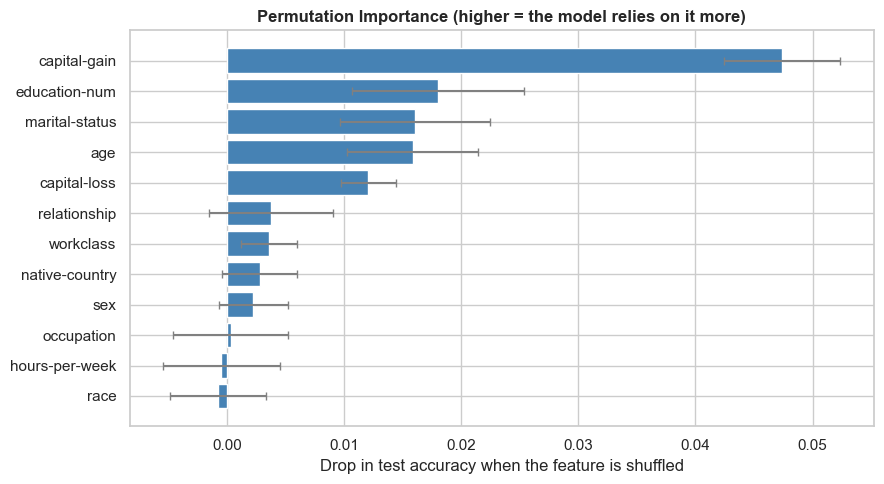

In [3]:
perm = permutation_importance(model, X_test, y_test, n_repeats=15, random_state=42, scoring='accuracy')
order = perm.importances_mean.argsort()

plt.figure(figsize=(9, 5))
plt.barh(np.array(feature_names)[order], perm.importances_mean[order],
         xerr=perm.importances_std[order], color='steelblue', ecolor='gray', capsize=3)
plt.xlabel('Drop in test accuracy when the feature is shuffled')
plt.title('Permutation Importance (higher = the model relies on it more)', fontweight='bold')
plt.tight_layout()
plt.show()


### How to Read This Chart: Permutation Importance

- **Each bar** is one feature; **length** = how much test accuracy fell when that feature was scrambled.
- **Error bars** = spread over 15 shuffles; wide bars mean the estimate is noisy.
- **Top bars** are the features the model truly depends on. **Bars near zero** barely affected accuracy — the
  model could almost ignore them.
- **A negative bar** (rare) means shuffling *helped* slightly — a sign that feature was adding noise.

> **Use it to:** sanity-check the model ("does it rely on sensible things?"), and as fast feature selection
> ("could I drop the bottom features?"). It's global — it says nothing about any single prediction.


## Step 4 — Partial Dependence Plots (Global)

Permutation importance tells you *which* features matter, but not *how*. **Partial Dependence Plots (PDP)**
answer the "how": as a feature goes up, does the predicted probability go **up, down, or wiggle**?

> **How it works (plain English):** to see the effect of `age`, PDP asks the model "what would you predict if
> everyone in the data were age 20? …age 30? …age 40?" — averaging over everything else. The resulting curve is
> the *average* effect of that one feature.


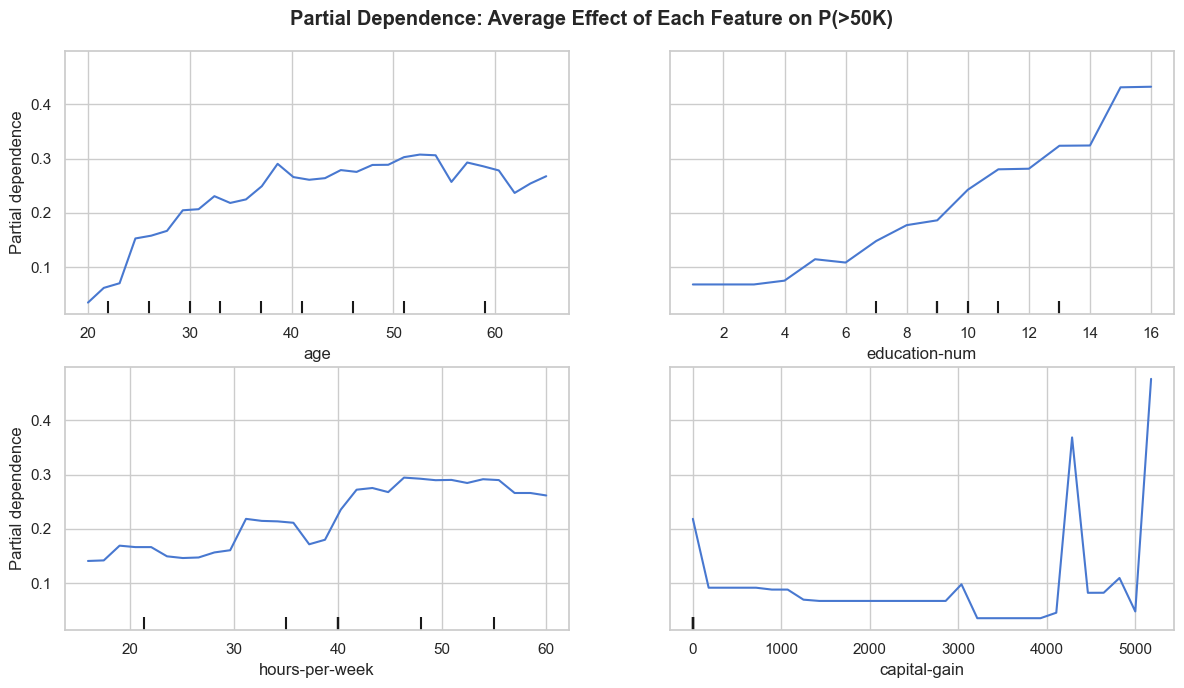

In [4]:
fig, ax = plt.subplots(figsize=(12, 7))
# PDP for four interpretable features. We pass a sample for speed.
PartialDependenceDisplay.from_estimator(
    model, X_test, ['age', 'education-num', 'hours-per-week', 'capital-gain'],
    ax=ax, n_cols=2, grid_resolution=30
)
fig.suptitle('Partial Dependence: Average Effect of Each Feature on P(>50K)', fontweight='bold')
plt.tight_layout()
plt.show()


### How to Read This Chart: Partial Dependence

- **X-axis** = the feature's value; **Y-axis** = the model's *average* predicted probability of >50K at that value.
- **An upward curve** means "more of this feature → higher predicted income." A **flat** curve means the feature
  barely moves the average prediction.
- **Shapes tell stories:** `age` and `education-num` typically rise then plateau; `hours-per-week` rises;
  `capital-gain` usually jumps sharply once it's above zero. These are the model's learned *relationships*.
- **The little ticks (rug) along the x-axis** show where the real data lies — trust the curve most where data
  is dense, and be skeptical where it's sparse.

> **Caution:** PDP shows the *average* effect. If the feature affects different people in opposite directions,
> the average can hide that — which is exactly what ICE curves (next) reveal.


## Step 5 — ICE Curves (Global that respects Individuals)

A PDP draws **one** average line. An **ICE plot (Individual Conditional Expectation)** draws **one line per
person** — showing how *each individual's* prediction would change as we sweep the feature. The PDP is just the
average of all those lines.

Why bother? Because **the average can lie.** If a feature pushes some people up and others down, the PDP looks
flat while ICE reveals the fan of diverging lines.


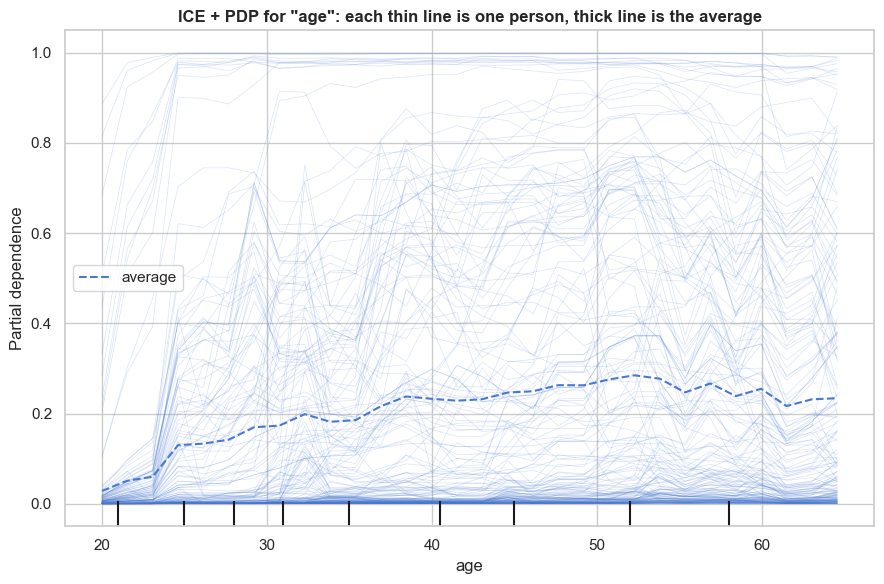

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
PartialDependenceDisplay.from_estimator(
    model, X_test.sample(200, random_state=42), ['age'],
    kind='both',          # 'both' = ICE lines (thin) + PDP (thick average line)
    ax=ax, grid_resolution=30, ice_lines_kw={'alpha': 0.2}
)
ax.set_title('ICE + PDP for "age": each thin line is one person, thick line is the average',
             fontweight='bold')
plt.tight_layout()
plt.show()


### How to Read This Chart: ICE Curves

- **Each thin line** = one individual — how *their* predicted probability would change as we vary only `age`.
- **The thick line** = the PDP (the average of all thin lines).
- **If the thin lines are roughly parallel**, the feature affects everyone the same way — the PDP is trustworthy.
- **If the thin lines fan out or cross**, the feature interacts with others: it helps some people and hurts
  others. The flat-looking average would have hidden that.

> **In one sentence:** PDP is the headline; ICE is the full story behind it.


## Step 6 — SHAP: Global View (Beeswarm)

**SHAP (SHapley Additive exPlanations)** is the most rigorous tool here. Rooted in cooperative game theory, it
fairly splits each prediction into per-feature **contributions** that provably add up to the prediction. Unlike
permutation importance, SHAP tells you the **direction** (did the feature push the prediction up or down?) and
does it **per sample**, then aggregates for a global view.

We use `TreeExplainer`, which is fast and exact for tree models like LightGBM.


SHAP values shape: (300, 12)  (people x features)


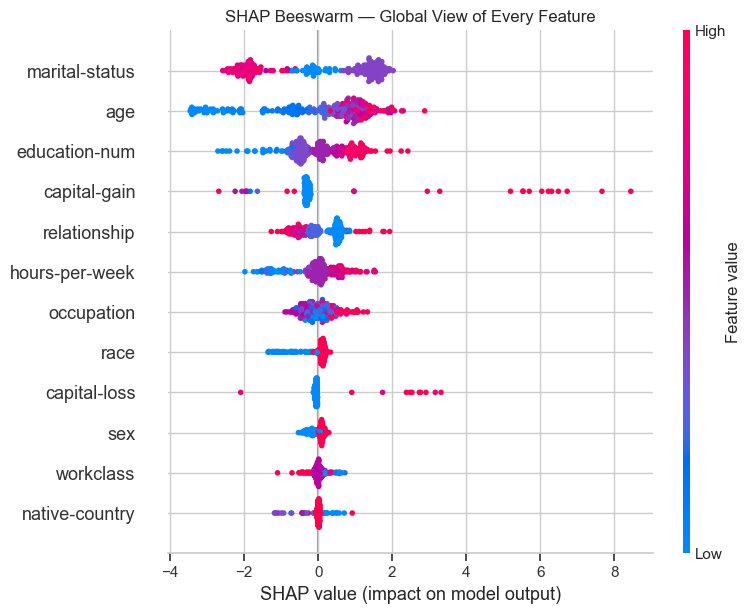

In [6]:
explainer = shap.TreeExplainer(model)
sample = X_test.iloc[:300]                 # explain 300 test people (SHAP is O(samples))
shap_values = explainer(sample)            # an Explanation object: .values are per-feature contributions
print(f"SHAP values shape: {np.array(shap_values.values).shape}  (people x features)")

shap.plots.beeswarm(shap_values, max_display=12, show=False)
plt.title('SHAP Beeswarm — Global View of Every Feature', fontsize=12)
plt.tight_layout()
plt.show()


### How to Read This Chart: SHAP Beeswarm

- **Each row** = a feature (sorted by overall importance, top = most important).
- **Each dot** = one person. Its **horizontal position** = that feature's SHAP value for them (how much it pushed
  their prediction). Right of center = pushed **toward >50K**; left = pushed **toward ≤50K**.
- **Color** = the feature's *value* for that person (red = high, blue = low).
- **Reading a row:** if the red dots sit on the right and blue on the left, "high values of this feature push
  the prediction up." For `capital-gain`, expect exactly that. If colors are mixed left-and-right, the effect
  depends on context (an interaction).

> **Why it beats a plain importance bar chart:** you see importance **and** direction **and** the spread across
> people, all at once.


## Step 7 — SHAP: Local View (Explain One Prediction)

Now the local question every stakeholder asks: *"Why THIS prediction?"* The **waterfall plot** breaks a single
person's prediction into feature contributions, starting from the model's average output and adding each
feature's push until it reaches the final prediction.


Person #0: model predicts P(>50K) = 0.025  (true label: 0)
Their feature values:
age               41
workclass          3
education-num      9
marital-status     0
occupation         2
relationship       4
race               4
sex                0
capital-gain       0
capital-loss       0
hours-per-week    60
native-country    38


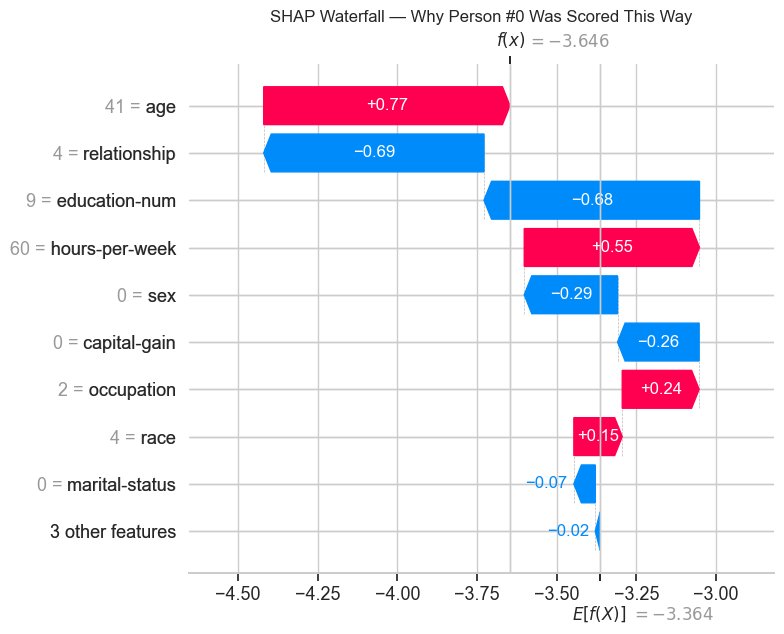

In [7]:
i = 0  # explain the first person in our sample
proba = model.predict_proba(sample.iloc[[i]])[0, 1]
print(f"Person #{i}: model predicts P(>50K) = {proba:.3f}  (true label: {y_test.iloc[i]})")
print("Their feature values:")
print(sample.iloc[i].to_string())

shap.plots.waterfall(shap_values[i], max_display=10, show=False)
plt.title(f'SHAP Waterfall — Why Person #{i} Was Scored This Way', fontsize=12)
plt.tight_layout()
plt.show()


### How to Read This Chart: SHAP Waterfall

- **Bottom (`E[f(x)]`)** = the model's average prediction over everyone — the starting point if we knew nothing
  about this person.
- **Each bar** = one feature's push. **Red bars push the prediction up** (toward >50K); **blue bars push it down**.
- **Top (`f(x)`)** = the final prediction for this specific person, after all pushes.
- **Read it as a sentence:** "Starting from the average, high capital-gain added +X, being married added +Y,
  young age subtracted −Z … landing at the final score."

> **This is the chart you hand a regulator or a customer.** It's an auditable, feature-by-feature justification
> for one decision.


## Step 8 — LIME: A Different Local Explainer

**LIME (Local Interpretable Model-agnostic Explanations)** answers the same "why this prediction?" question with
a completely different strategy:

> LIME **wiggles** the input (creates many slightly-altered copies of the person), asks the black box to score
> all of them, and fits a **simple linear model** to that local cloud. The simple model's coefficients become the
> explanation — valid *near this one point*, even though the global model is wildly non-linear.

It's **model-agnostic** (works on any model, not just trees) — its big selling point over tree-specific SHAP.
Let's explain the **same person** and compare.


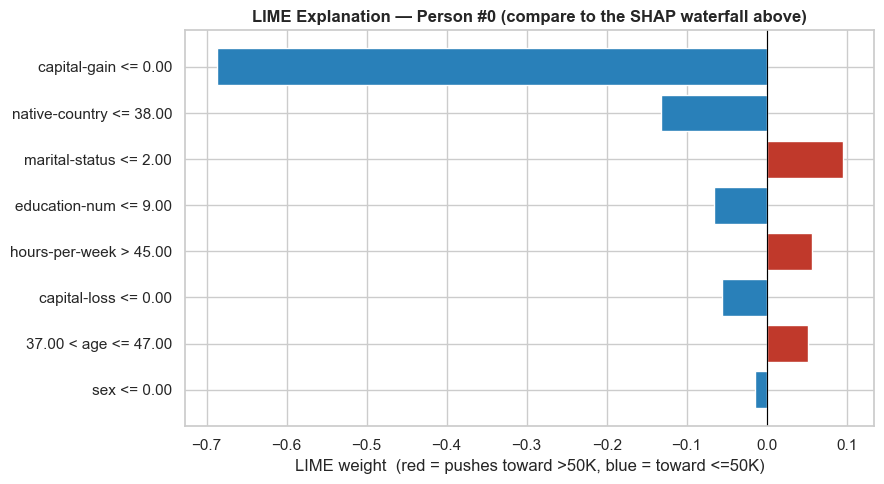

In [8]:
lime_explainer = LimeTabularExplainer(
    X_train.values, feature_names=feature_names, class_names=['<=50K', '>50K'],
    mode='classification', discretize_continuous=True, random_state=42
)
exp = lime_explainer.explain_instance(sample.values[i], model.predict_proba, num_features=8)

# LIME gives (condition, weight) pairs; positive weight pushes toward >50K.
pairs = exp.as_list()
labels = [p[0] for p in pairs][::-1]
weights = [p[1] for p in pairs][::-1]
colors = ['#c0392b' if w > 0 else '#2980b9' for w in weights]

plt.figure(figsize=(9, 5))
plt.barh(labels, weights, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('LIME weight  (red = pushes toward >50K, blue = toward <=50K)')
plt.title(f'LIME Explanation — Person #{i} (compare to the SHAP waterfall above)', fontweight='bold')
plt.tight_layout()
plt.show()


### How to Read This Chart: LIME

- **Each bar** is a **condition** LIME found locally important (e.g. `capital-gain <= 0.00`,
  `marital-status > 2`), not just a feature name — LIME buckets continuous features into ranges.
- **Bar direction/color:** red bars push this person toward >50K; blue bars push toward ≤50K.
- **Compare to SHAP (Step 7):** the two methods use totally different math, so they won't match exactly — but
  the *top drivers usually agree*. When SHAP and LIME agree on the main reasons, you can trust the explanation
  more. When they disagree wildly, dig deeper before trusting either.

> **SHAP vs LIME in one line:** SHAP is exact and consistent (and fast for trees); LIME is simple, intuitive, and
> works on any model, but its explanations can vary between runs because of the random sampling.


## Step 9 — Surrogate Model: Mimic the Black Box with a Readable Tree

A final, very intuitive global technique: **train a simple, interpretable model to imitate the black box.**

> We take a shallow **decision tree** and train it — *not* on the true labels, but on the **black box's own
> predictions**. If the little tree can reproduce the black box's outputs well (high **fidelity**), then reading
> the tree gives us a readable approximation of the black box's logic.

The catch: it's only a summary. High fidelity = trust the tree as an explanation; low fidelity = the black box
is doing something too complex for a small tree to capture.


Surrogate fidelity (agreement with the black box on test): 89.1%
Higher = the simple tree is a faithful summary of the complex model's logic.


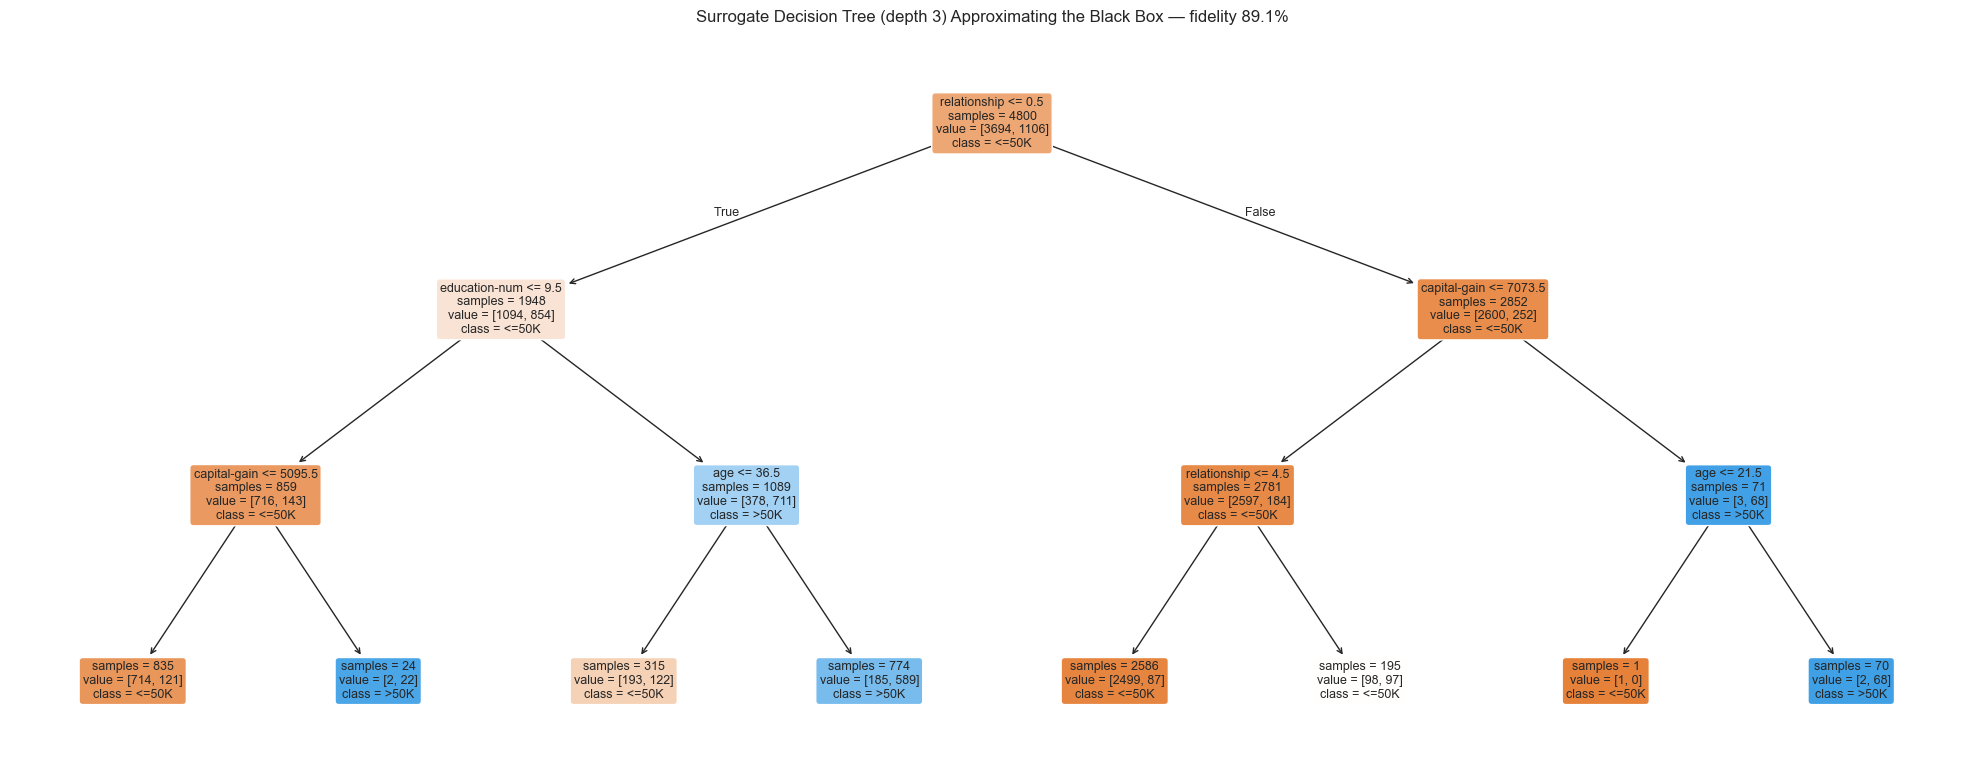

In [9]:
# Train a depth-3 tree to predict what the BLACK BOX predicts (not the true y)
bb_train_pred = model.predict(X_train)
surrogate = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, bb_train_pred)

# Fidelity = how often the surrogate agrees with the black box on the TEST set
fidelity = accuracy_score(model.predict(X_test), surrogate.predict(X_test))
print(f"Surrogate fidelity (agreement with the black box on test): {fidelity:.1%}")
print("Higher = the simple tree is a faithful summary of the complex model's logic.")

plt.figure(figsize=(20, 8))
plot_tree(surrogate, feature_names=feature_names, class_names=['<=50K', '>50K'],
          filled=True, rounded=True, fontsize=9, impurity=False)
plt.title(f'Surrogate Decision Tree (depth 3) Approximating the Black Box — fidelity {fidelity:.1%}',
          fontsize=12)
plt.tight_layout()
plt.show()


### How to Read This Chart: Surrogate Tree

- **Read top to bottom:** each box asks a yes/no question about one feature; go left if true, right if false.
- **Leaf color** = the class the black box tends to predict for people who land there (orange ≈ ≤50K,
  blue ≈ >50K); darker = more one-sided.
- **The root split** is the single question that best separates the black box's own decisions — often the same
  feature SHAP and permutation importance flagged as #1. That agreement across methods is reassuring.
- **Fidelity in the title** tells you how much to trust this simplification. At high fidelity, this tree *is* a
  fair, human-readable story of the model. At low fidelity, treat it as a rough sketch only.


## Step 10 — Interpreting a Regression Model

Every method above works for regression too — the only change is that the "output" is a number (a price)
instead of a probability. Here's a quick PDP on an Ames Housing model, showing how predicted **sale price**
responds to overall quality and living area.


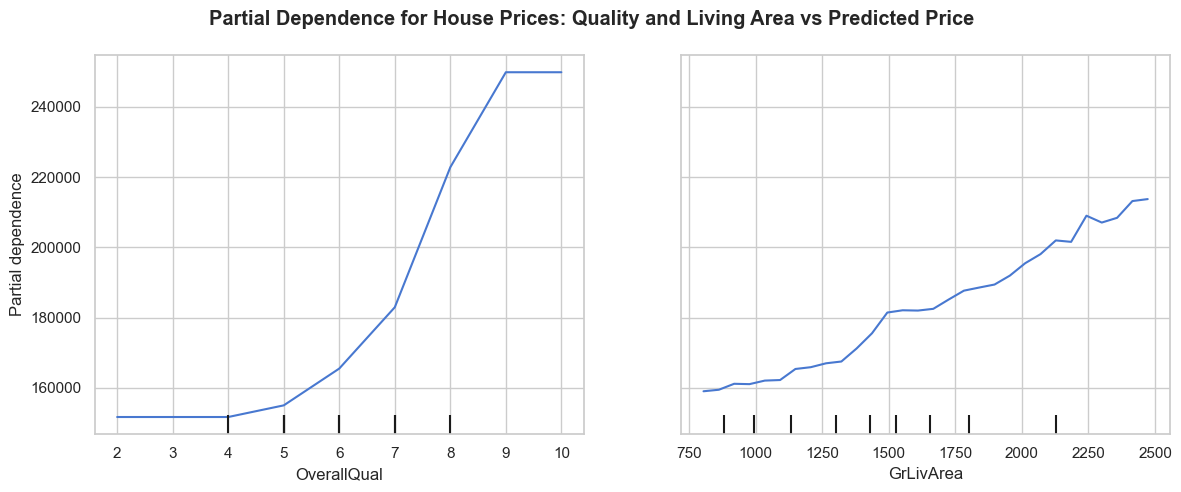

Read exactly like the classification PDPs — Y is now predicted dollars instead of a probability.


In [10]:
ames = fetch_openml('house_prices', as_frame=True).frame
yh = ames['SalePrice'].astype(float)
Xh = ames.drop(columns=['SalePrice', 'Id'], errors='ignore').copy()
for c in Xh.select_dtypes(include='number').columns:
    Xh[c] = Xh[c].fillna(Xh[c].median())
for c in Xh.select_dtypes(exclude='number').columns:
    Xh[c] = Xh[c].astype('object').fillna('None').astype('category').cat.codes
Xh_tr, Xh_te, yh_tr, yh_te = train_test_split(Xh, yh, test_size=0.2, random_state=42)
reg = LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42, verbose=-1).fit(Xh_tr, yh_tr)

fig, ax = plt.subplots(figsize=(12, 5))
PartialDependenceDisplay.from_estimator(reg, Xh_te, ['OverallQual', 'GrLivArea'], ax=ax, n_cols=2,
                                        grid_resolution=30)
fig.suptitle('Partial Dependence for House Prices: Quality and Living Area vs Predicted Price',
             fontweight='bold')
plt.tight_layout()
plt.show()
print("Read exactly like the classification PDPs — Y is now predicted dollars instead of a probability.")


## Step 11 — Summary and Key Takeaways

### The six tools at a glance

| Method | Global or Local? | Model-agnostic? | Tells you… |
|--------|------------------|-----------------|------------|
| **Permutation Importance** | Global | Yes | *Which* features matter (by shuffling) |
| **Partial Dependence (PDP)** | Global | Yes | *How* a feature affects the average prediction |
| **ICE curves** | Global + Individual | Yes | Whether that effect is the same for everyone |
| **SHAP** | Global **and** Local | Tree-fast / model-agnostic (slow) | Signed, consistent contributions; the rigorous default |
| **LIME** | Local | Yes | A quick local linear story; great for non-tree models |
| **Surrogate tree** | Global | Yes | A readable approximation of the whole model |

### Which should I use?

```
Need to justify ONE decision (to a customer/regulator)?  → SHAP waterfall (or LIME if not a tree model)
Want the overall drivers and their direction?            → SHAP beeswarm (or permutation importance)
Want the SHAPE of a feature's effect?                    → PDP, and ICE to check it holds for everyone
Want a simple readable summary of the whole model?       → Surrogate tree (check its fidelity!)
```

### Common mistakes to avoid
1. **Confusing importance with direction.** Permutation importance says a feature *matters*, not *which way* it
   pushes. Use SHAP for direction.
2. **Trusting a PDP blindly.** If features interact, the average PDP can hide it — always glance at ICE.
3. **Reading a low-fidelity surrogate as truth.** If the surrogate can't reproduce the black box, its "story" is
   fiction. Always report fidelity.
4. **Explaining ≠ justifying bias.** Interpretability can *reveal* that a model leans on a sensitive attribute —
   that's a finding to act on, not to rationalize.
5. **Ignoring correlated features.** When two features are correlated, all these methods can split or shuffle
   credit between them. Interpret related features together.

### What's next?
The final notebook in this series turns a trained, understood model into **good decisions** — choosing the right
**threshold**, reading ROC vs precision-recall curves, and accounting for the cost of different mistakes.

---

*Notebook by Shivani Bokka — Dive Deeper into Supervised Learning Series*
